In [1]:
import pandas as pd
import numpy as np

# 读取 Excel
file_path = "../data/raw/Online Retail.xlsx"

df = pd.read_excel(file_path)

print("Shape:", df.shape)
df.head()
df.info()

Shape: (541909, 8)
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB


In [2]:
df.shape
df.columns
df.head(3)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom


In [3]:
# Create a working copy of the dataset
df_clean = df.copy()

# Remove rows with missing customer identifiers
df_clean = df_clean.dropna(subset=["CustomerID"])

# Remove cancelled or returned transactions (negative quantity)
df_clean = df_clean[df_clean["Quantity"] > 0]

# Remove invalid or zero pricing entries
df_clean = df_clean[df_clean["UnitPrice"] > 0]

# Create transaction monetary value
df_clean["Amount"] = df_clean["Quantity"] * df_clean["UnitPrice"]

# Convert customer identifier to string for consistency
df_clean["CustomerID"] = df_clean["CustomerID"].astype(str)

# Reset index after filtering
df_clean = df_clean.reset_index(drop=True)

print("Cleaned dataset shape:", df_clean.shape)

Cleaned dataset shape: (397884, 9)


In [4]:
# Summary statistics after cleaning
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,Amount
count,397884.000000,397884,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023,3.116488,22.397000
min,1.000000,2010-12-01 08:26:00,0.001000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,168469.600000
std,179.331775,NaN,22.097877,309.071041


In [5]:
# Define snapshot date as the last transaction date in dataset
snapshot_date = df_clean["InvoiceDate"].max()

print("Snapshot date:", snapshot_date)

Snapshot date: 2011-12-09 12:50:00


In [6]:
# Aggregate transactional data to customer-level RFM metrics

rfm = df_clean.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,  # Recency
    "InvoiceNo": "nunique",                                   # Frequency
    "Amount": "sum"                                            # Monetary
}).reset_index()

# Rename columns
rfm.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,1,77183.60
1,12347.0,1,7,4310.00
2,12348.0,74,4,1797.24
3,12349.0,18,1,1757.55
4,12350.0,309,1,334.40


In [7]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,91.536422,4.272015,2054.266460
std,100.014169,7.697998,8989.230441
min,0.000000,1.000000,3.750000
25%,17.000000,1.000000,307.415000
50%,50.000000,2.000000,674.485000
75%,141.000000,5.000000,1661.740000
max,373.000000,209.000000,280206.020000


In [8]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# Apply log transformation to reduce skewness
rfm_log = rfm.copy()
rfm_log["Recency"] = np.log1p(rfm_log["Recency"])
rfm_log["Frequency"] = np.log1p(rfm_log["Frequency"])
rfm_log["Monetary"] = np.log1p(rfm_log["Monetary"])

# Standardize features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_log[["Recency", "Frequency", "Monetary"]])

rfm_scaled[:5]

array([[ 1.40989446, -0.95521426,  3.70622476],
       [-2.14649825,  1.07442519,  1.41184341],
       [ 0.38397128,  0.38630445,  0.7164889 ],
       [-0.57467446, -0.95521426,  0.6987394 ],
       [ 1.37475812, -0.95521426, -0.6189622 ]])

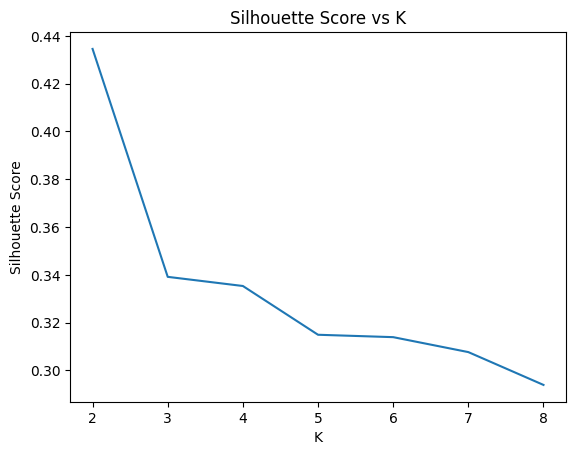

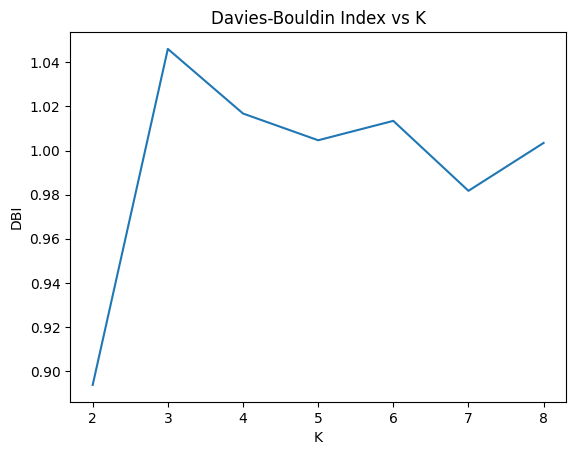

In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

import matplotlib.pyplot as plt

silhouette_scores = []
dbi_scores = []

K_range = range(2, 9)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(rfm_scaled)

    silhouette_scores.append(silhouette_score(rfm_scaled, labels))
    dbi_scores.append(davies_bouldin_score(rfm_scaled, labels))

# Plot Silhouette
plt.figure()
plt.plot(K_range, silhouette_scores)
plt.title("Silhouette Score vs K")
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.show()

# Plot DBI
plt.figure()
plt.plot(K_range, dbi_scores)
plt.title("Davies-Bouldin Index vs K")
plt.xlabel("K")
plt.ylabel("DBI")
plt.show()

In [10]:
# Train final KMeans model with chosen K
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=20)
rfm["Cluster"] = kmeans_final.fit_predict(rfm_scaled)

rfm.head()

,CustomerID,Recency,Frequency,Monetary,Cluster
0,12346.0,325,1,77183.60,0
1,12347.0,1,7,4310.00,1
2,12348.0,74,4,1797.24,0
3,12349.0,18,1,1757.55,2
4,12350.0,309,1,334.40,3


In [11]:
# Compute average RFM per cluster
cluster_profile = rfm.groupby("Cluster")[["Recency", "Frequency", "Monetary"]].mean()

cluster_profile

,Recency,Frequency,Monetary
Cluster,,,
0,68.120000,4.179167,1829.636994
1,10.546110,13.909222,8225.799769
2,17.090571,2.114144,543.467730
3,179.637973,1.318681,347.438023


In [12]:
# Define cutoff date 30 days before snapshot
cutoff_date = snapshot_date - pd.Timedelta(days=30)

print("Cutoff date:", cutoff_date)

Cutoff date: 2011-11-09 12:50:00


In [13]:
# Split dataset into historical observation window
df_train_period = df_clean[df_clean["InvoiceDate"] <= cutoff_date]

print("Training period shape:", df_train_period.shape)

Training period shape: (332310, 9)


In [14]:
# Recompute RFM using only historical data before cutoff

rfm_train = df_train_period.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (cutoff_date - x.max()).days,
    "InvoiceNo": "nunique",
    "Amount": "sum"
}).reset_index()

rfm_train.columns = ["CustomerID", "Recency", "Frequency", "Monetary"]

rfm_train.head()

,CustomerID,Recency,Frequency,Monetary
0,12346.0,295,1,77183.60
1,12347.0,9,6,4085.18
2,12348.0,44,4,1797.24
3,12350.0,279,1,334.40
4,12352.0,5,8,2506.04


In [15]:
# Define prediction window (30 days after cutoff)
df_future_period = df_clean[
    (df_clean["InvoiceDate"] > cutoff_date) &
    (df_clean["InvoiceDate"] <= snapshot_date)
]

print("Future period shape:", df_future_period.shape)

Future period shape: (65574, 9)


In [16]:
# Customers who made at least one purchase in prediction window
active_future_customers = df_future_period["CustomerID"].unique()

# Create churn label
rfm_train["Churn"] = ~rfm_train["CustomerID"].isin(active_future_customers)

rfm_train["Churn"] = rfm_train["Churn"].astype(int)

rfm_train.head()

,CustomerID,Recency,Frequency,Monetary,Churn
0,12346.0,295,1,77183.60,1
1,12347.0,9,6,4085.18,0
2,12348.0,44,4,1797.24,1
3,12350.0,279,1,334.40,1
4,12352.0,5,8,2506.04,1


In [17]:
rfm_train["Churn"].value_counts(normalize=True)

Churn
1    0.660934
0    0.339066
Name: proportion, dtype: float64

In [18]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Copy dataset
model_df = rfm_train.copy()

# Log transform
model_df["Recency"] = np.log1p(model_df["Recency"])
model_df["Frequency"] = np.log1p(model_df["Frequency"])
model_df["Monetary"] = np.log1p(model_df["Monetary"])

# Features and target
X = model_df[["Recency", "Frequency", "Monetary"]]
y = model_df["Churn"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (2849, 3)
Test size: (1221, 3)


In [19]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, f1_score, classification_report

# Initialize model
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss"
)

# Train
xgb_model.fit(X_train, y_train)

# Predict
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

# Metrics
auc = roc_auc_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)

print("AUC:", auc)
print("F1:", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

AUC: 0.7208603463654376
F1: 0.7974828375286042

Classification Report:

              precision    recall  f1-score   support

           0       0.61      0.41      0.49       414
           1       0.74      0.86      0.80       807

    accuracy                           0.71      1221
   macro avg       0.67      0.64      0.64      1221
weighted avg       0.70      0.71      0.69      1221



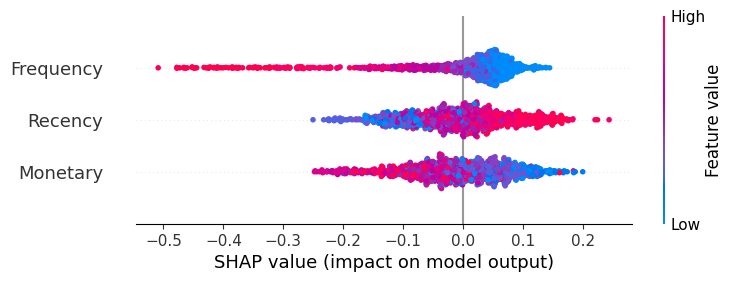

In [22]:
import shap
import numpy as np

# Use a small background sample for speed
background = shap.sample(X_train, 200, random_state=42)

# Build a model-agnostic explainer over predict_proba
explainer = shap.Explainer(xgb_model.predict_proba, background)

# Explain the positive class (churn=1)
shap_values = explainer(X_test)

# Summary plot for class 1
shap.plots.beeswarm(shap_values[:, :, 1])